# Heterogeneous Ligand Model: Association, Dissociation, and Steady State

This notebook simulates a surface response for a 2:1 heterogeneous ligand interaction. The measured signal is modeled as the sum of two independent 1:1 binding interactions, with `fraction_site1` controlling how much of the total response comes from the higher-affinity site.
        

In [1]:
import numpy as np
import plotly.graph_objs as go

from pykingenie.utils.signal_surface import (
    steady_state_two_site_heterogeneous_ligand,
    solve_two_site_heterogeneous_ligand_association,
    solve_two_site_heterogeneous_ligand_dissociation,
)
from pykingenie.utils.plotting import plot_traces
from pykingenie.utils.palettes import VIRIDIS
from notebook_helpers import show_plotly_static
        

## Parameters

- `Kd1`: dissociation constant for site 1. This example treats site 1 as the higher-affinity site, so `Kd1 < Kd2`.
- `koff1`, `koff2`: dissociation rate constants for each site.
- `Rmax`: total maximum response from both ligand interactions.
- `fraction_site1`: fraction of the total response contributed by site 1. Site 2 contributes `1 - fraction_site1`.

Concentrations are in uM and time is in seconds.
        

In [2]:
Kd1 = 0.08
Kd2 = 4.0
koff1 = 0.02
koff2 = 0.15

Rmax = 1.2
fraction_site1 = 0.35

if Kd1 >= Kd2:
    raise ValueError("Use Kd1 < Kd2 so site 1 is the higher-affinity site.")
if not 0 <= fraction_site1 <= 1:
    raise ValueError("fraction_site1 must be between 0 and 1.")
        

In [3]:
concentrations = np.logspace(-2, 1, 6)
t_assoc = np.linspace(0, 100, 400)
t_disso = np.linspace(0, 100, 400)

colors = [VIRIDIS[int(i)] for i in np.linspace(0, len(VIRIDIS) - 1, len(concentrations))]
        

In [4]:
combined_xs, combined_ys, legends = [], [], []
site1_endpoints, site2_endpoints = [], []

for conc in concentrations:
    assoc_matrix = solve_two_site_heterogeneous_ligand_association(
        time=t_assoc,
        a_conc=conc,
        Kd1=Kd1,
        koff1=koff1,
        Kd2=Kd2,
        koff2=koff2,
        Rmax=Rmax,
        fraction_site1=fraction_site1,
    )
    y_assoc = assoc_matrix[:, 0]

    # Dissociation starts from the component responses at the end of association.
    disso_matrix = solve_two_site_heterogeneous_ligand_dissociation(
        time=t_disso,
        koff1=koff1,
        koff2=koff2,
        fraction_site1=fraction_site1,
        s1_0=assoc_matrix[-1, 1],
        s2_0=assoc_matrix[-1, 2],
    )
    y_disso = disso_matrix[:, 0]

    combined_xs.append([t_assoc, t_disso + t_assoc[-1]])
    combined_ys.append([y_assoc, y_disso])
    legends.append(f"{conc:.3g} uM")
    site1_endpoints.append(assoc_matrix[-1, 1])
    site2_endpoints.append(assoc_matrix[-1, 2])

show = [True] * len(concentrations)
        

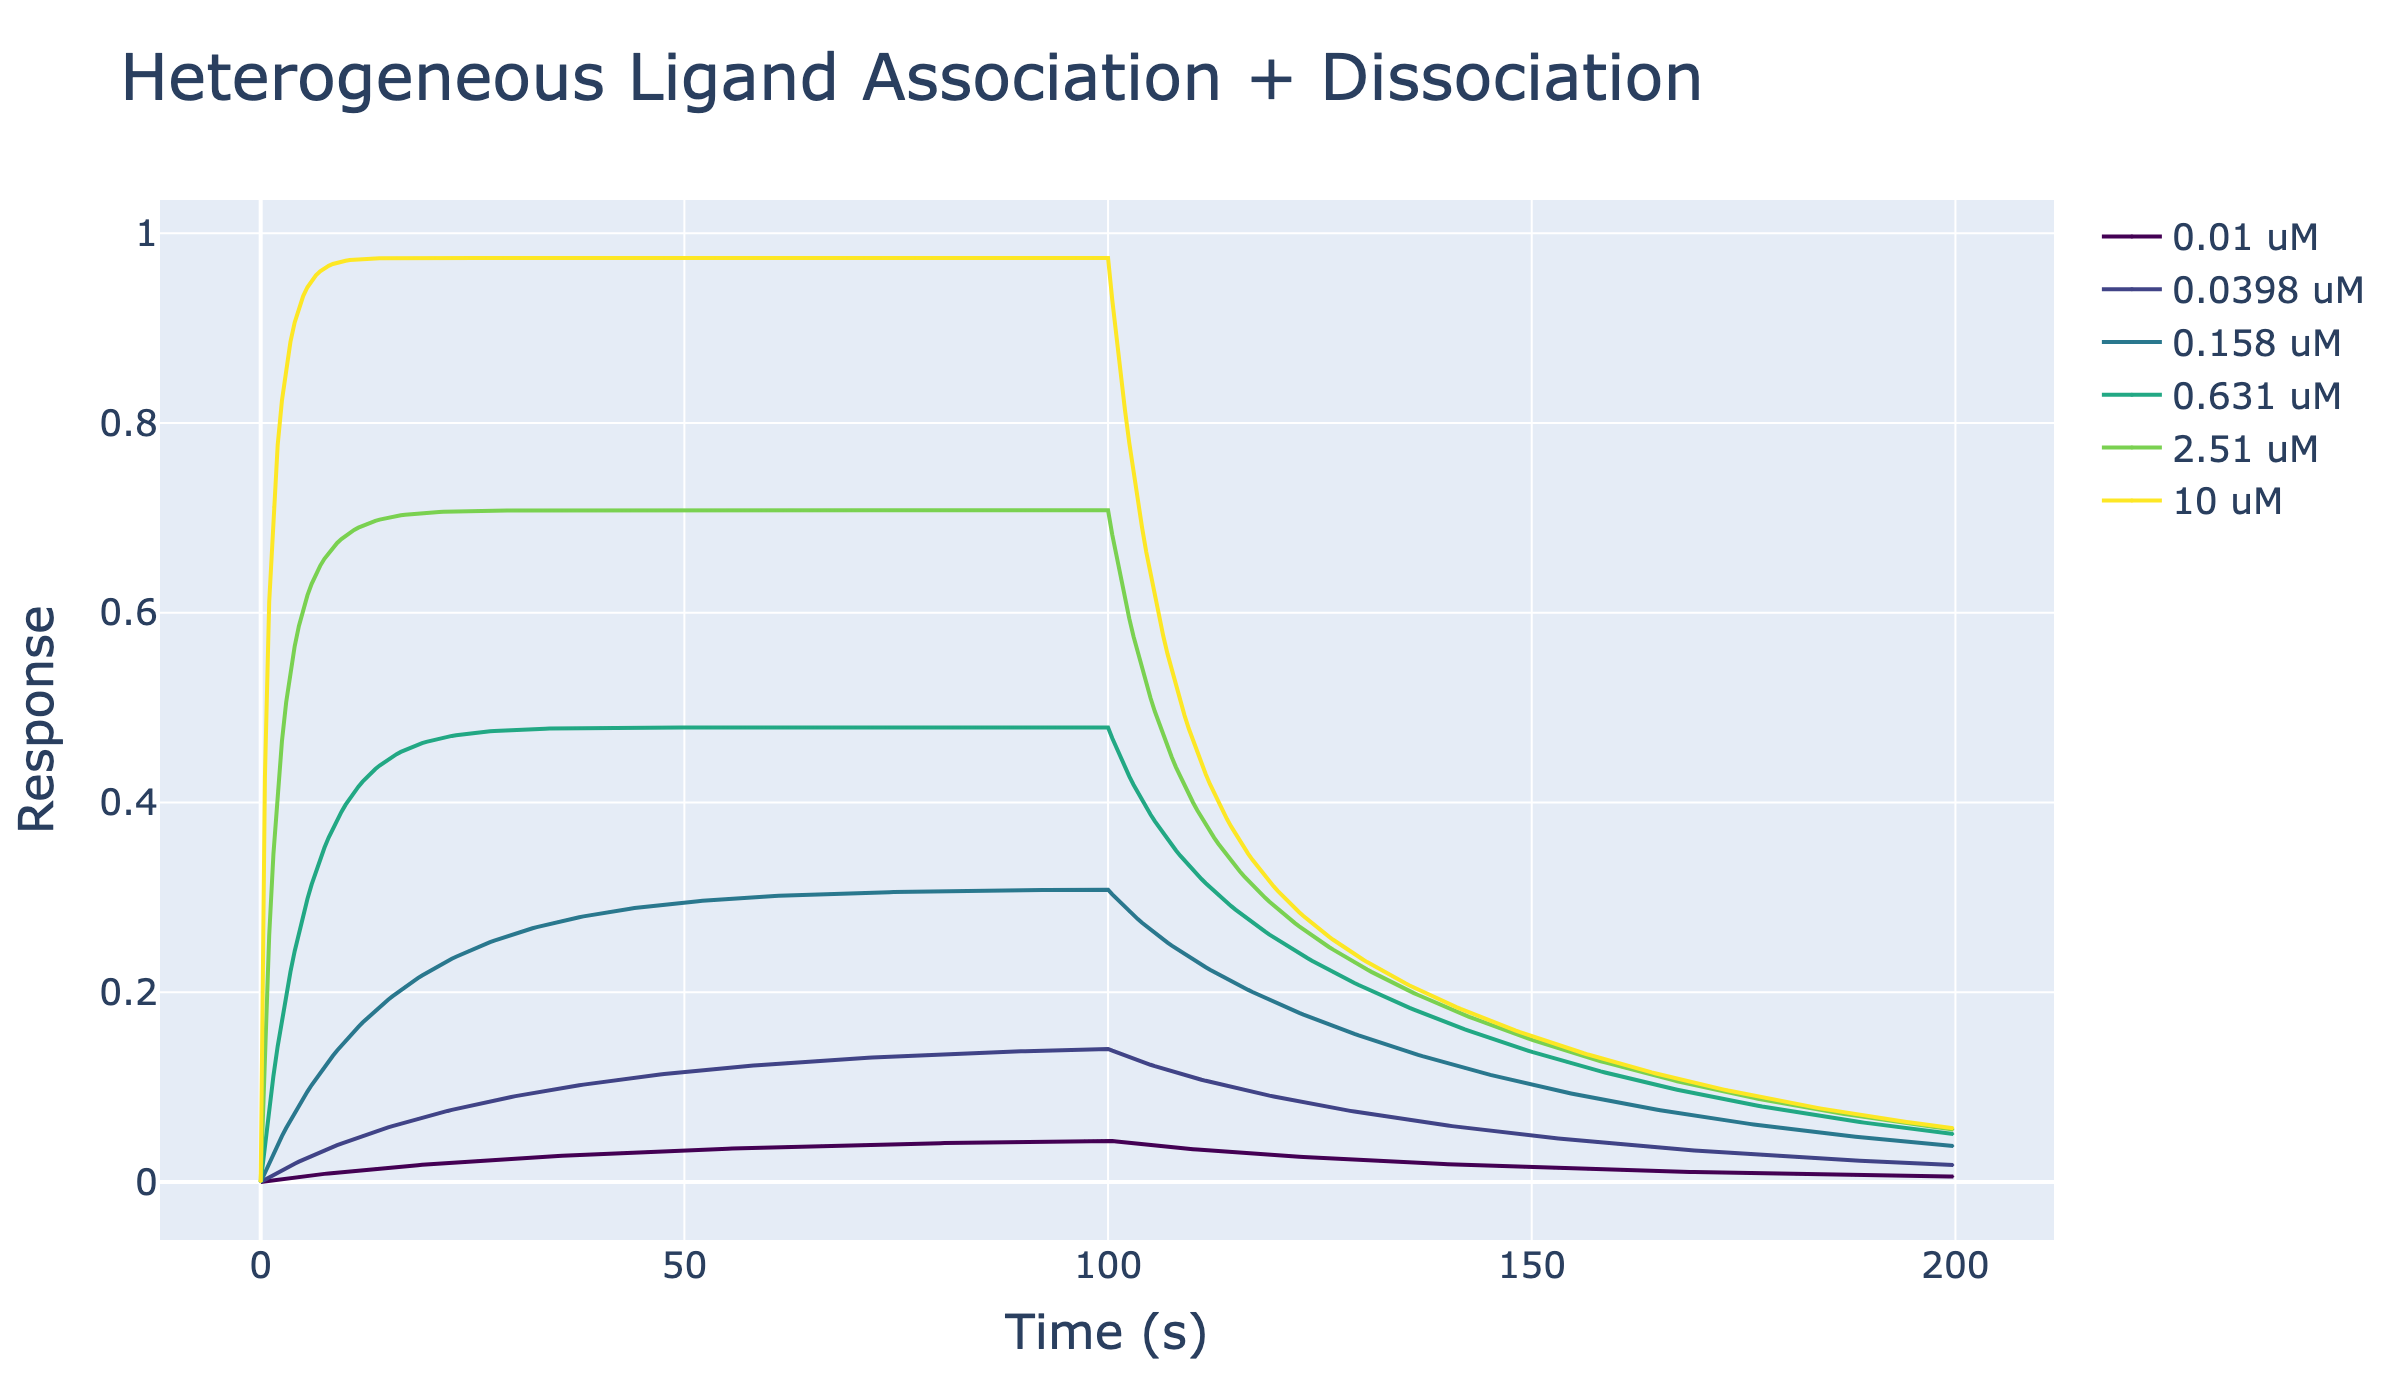

In [5]:
fig = plot_traces(
    xs=combined_xs,
    ys=combined_ys,
    legends=legends,
    colors=colors,
    show=show,
    marker_size=1,
    line_width=2,
)

fig.update_layout(
    title={"text": "Heterogeneous Ligand Association + Dissociation", "font": {"size": 32}},
    xaxis_title="Time (s)",
    yaxis_title="Response",
    font={"size": 20},
    legend={"font": {"size": 18}},
)
fig.update_xaxes(title_font={"size": 24}, tickfont={"size": 18})
fig.update_yaxes(title_font={"size": 24}, tickfont={"size": 18})

show_plotly_static(fig)
        

## Steady-State Signal

At equilibrium, the model is the weighted sum of the two 1:1 binding isotherms. Plotting the components makes the response split explicit.
        

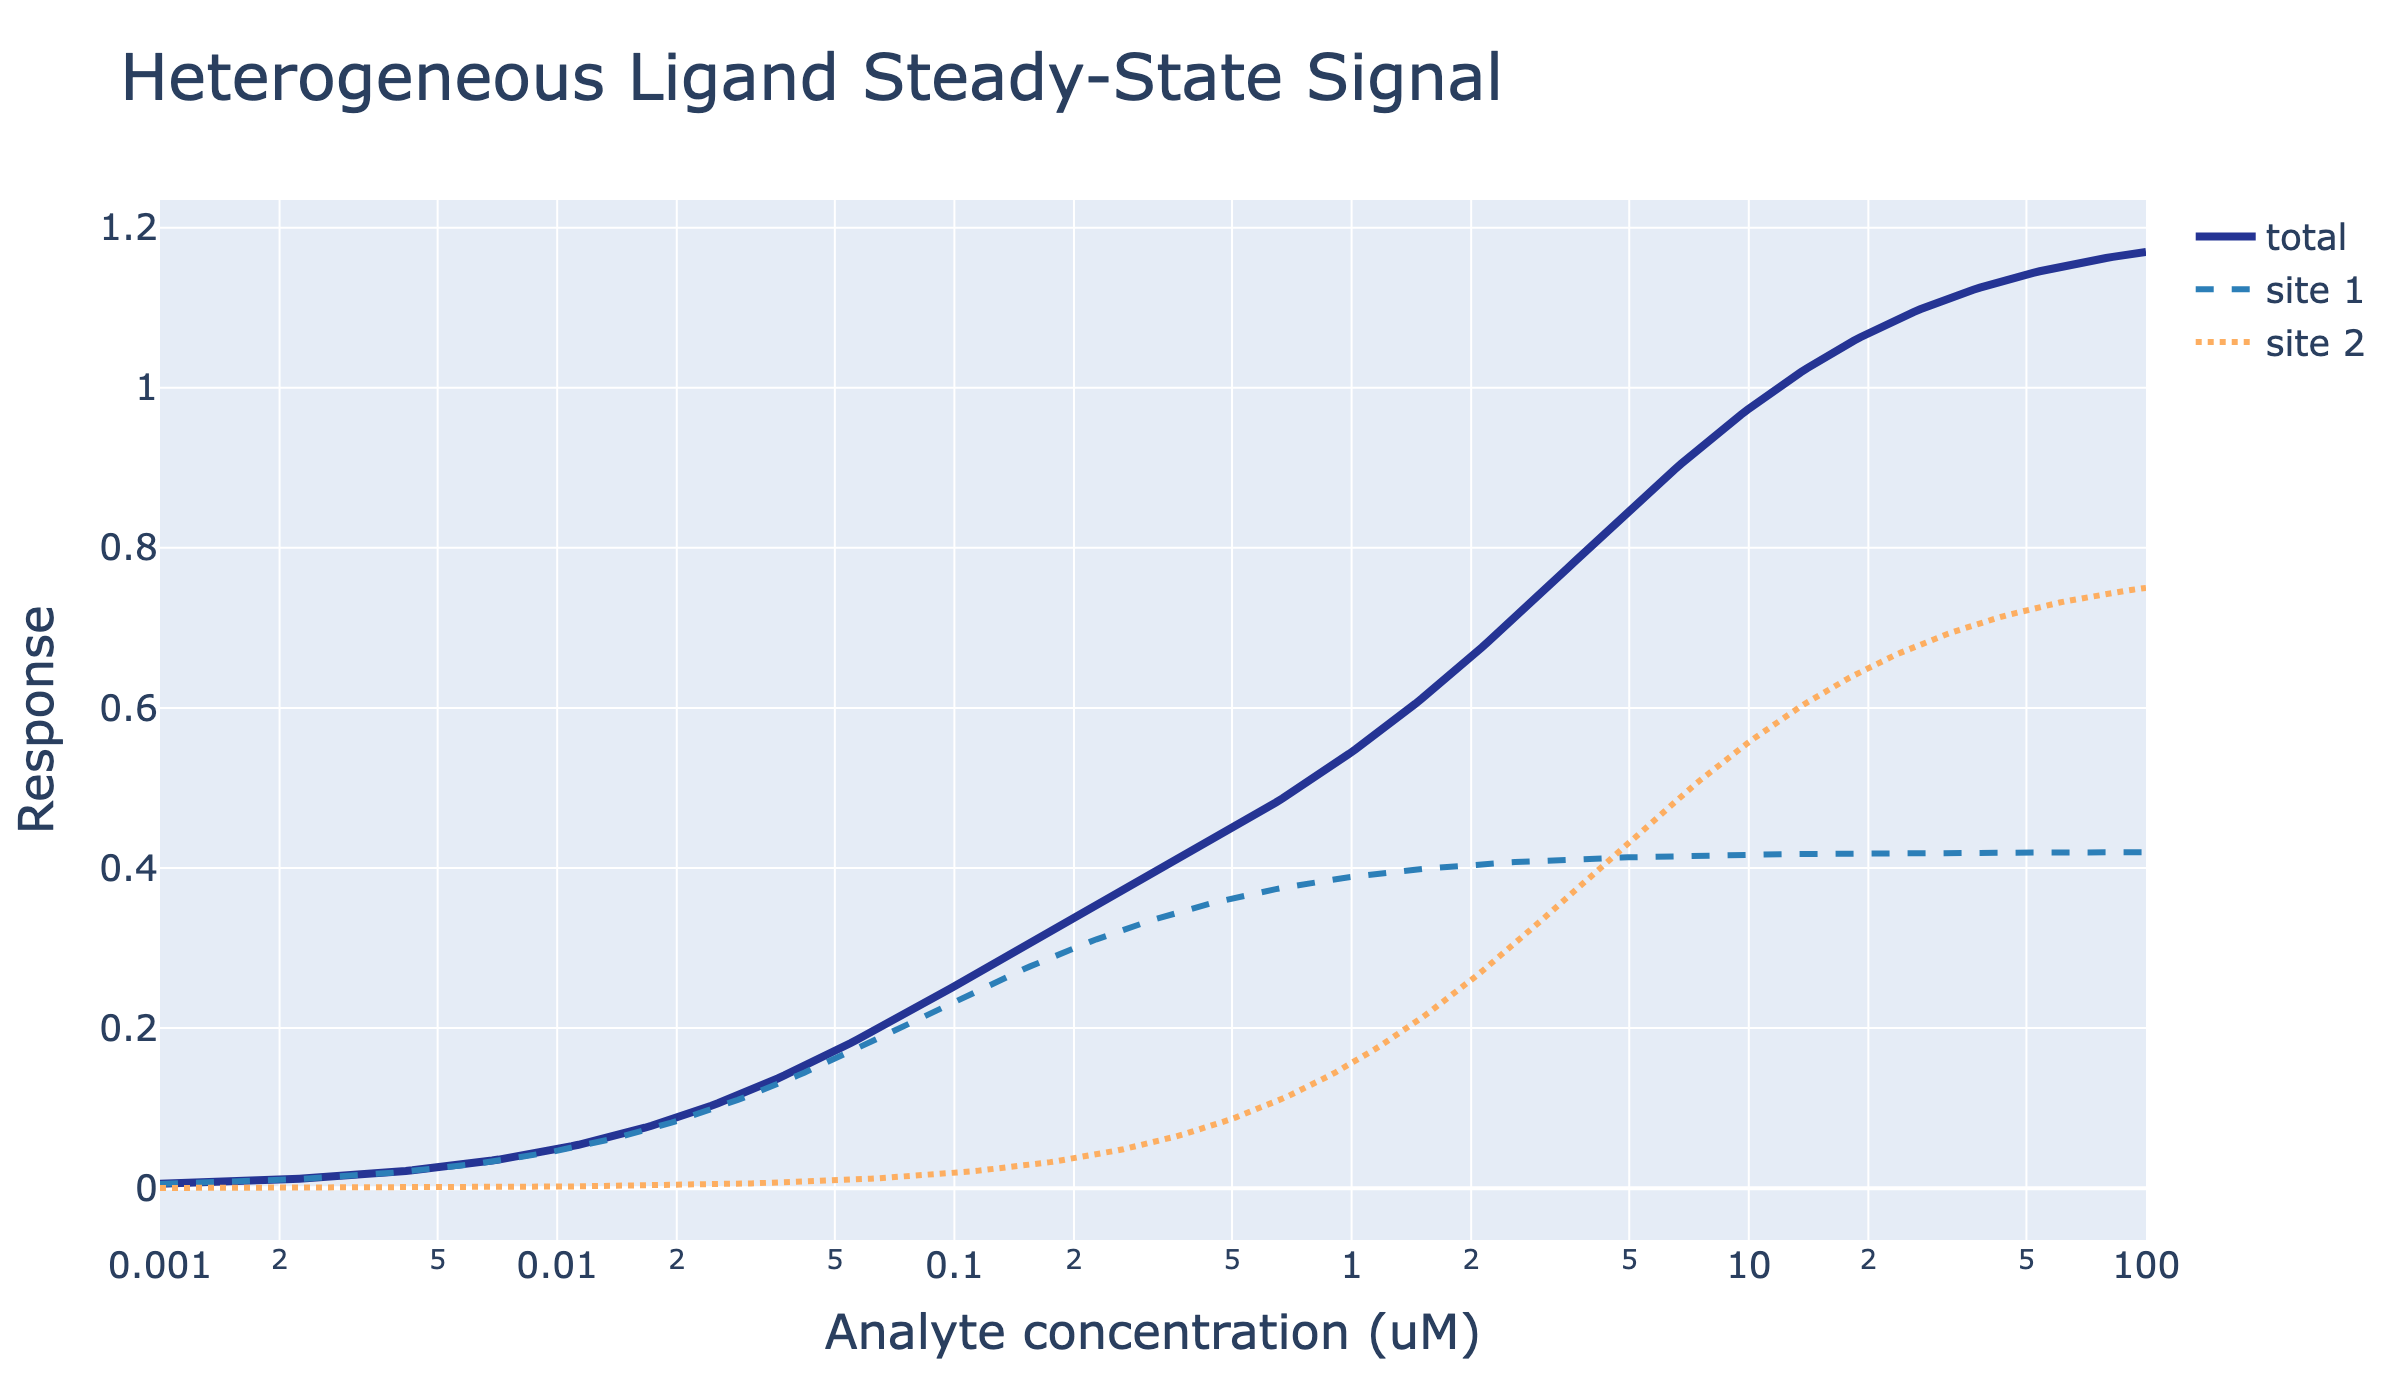

In [6]:
C_ss = np.logspace(-3, 2, 300)
Rmax1 = Rmax * fraction_site1
Rmax2 = Rmax * (1 - fraction_site1)
site1 = Rmax1 * C_ss / (Kd1 + C_ss)
site2 = Rmax2 * C_ss / (Kd2 + C_ss)
total = steady_state_two_site_heterogeneous_ligand(C_ss, Rmax, Kd1, Kd2, fraction_site1)

fig_ss = go.Figure()
fig_ss.add_trace(go.Scatter(x=C_ss, y=total, mode="lines", name="total", line={"width": 4, "color": "#253494"}))
fig_ss.add_trace(go.Scatter(x=C_ss, y=site1, mode="lines", name="site 1", line={"width": 3, "dash": "dash", "color": "#2c7fb8"}))
fig_ss.add_trace(go.Scatter(x=C_ss, y=site2, mode="lines", name="site 2", line={"width": 3, "dash": "dot", "color": "#fdae61"}))

fig_ss.update_layout(
    title={"text": "Heterogeneous Ligand Steady-State Signal", "font": {"size": 32}},
    xaxis_title="Analyte concentration (uM)",
    yaxis_title="Response",
    xaxis_type="log",
    font={"size": 20},
    legend={"font": {"size": 18}},
)
fig_ss.update_xaxes(title_font={"size": 24}, tickfont={"size": 18})
fig_ss.update_yaxes(title_font={"size": 24}, tickfont={"size": 18})

show_plotly_static(fig_ss)
        